In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv(r"C:/Users/RAMESH GAMARE/Downloads/netflix_dataset.csv")

In [4]:
data.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [5]:
print(data.isnull().sum())

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [6]:
data.drop_duplicates()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [8]:
data['date_added'] = pd.to_datetime(data['date_added'], format = "mixed", dayfirst = True)

In [9]:
data['year_added'] = data['date_added'].dt.year

In [10]:
data['month_added'] = data['date_added'].dt.month

In [11]:
content_count = data['year_added'].value_counts().sort_index()
content_count = content_count.reset_index()
content_count.columns = ['year_added', 'content_count']

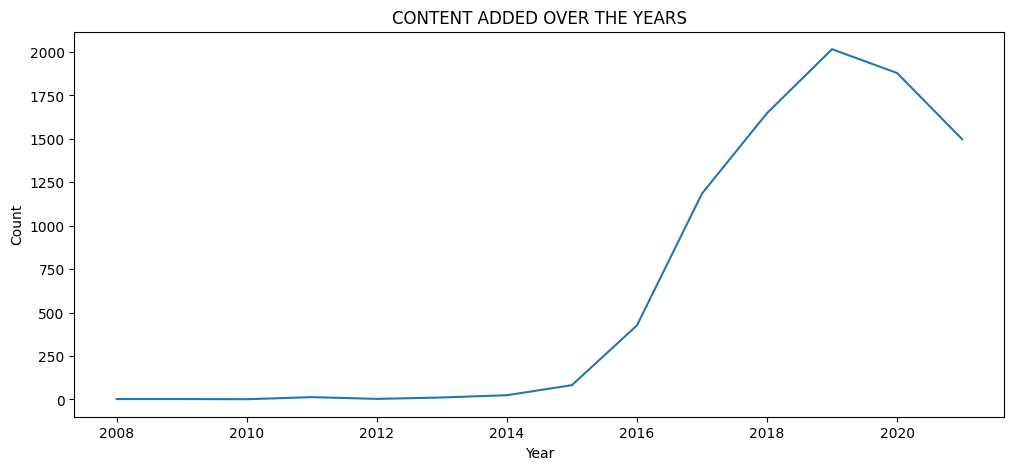

In [12]:
plt.figure(figsize = (12, 5))
sns.lineplot(x = 'year_added', y= 'content_count', data = content_count)
plt.title('CONTENT ADDED OVER THE YEARS')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

In [13]:
 most_type = data['type'].value_counts()

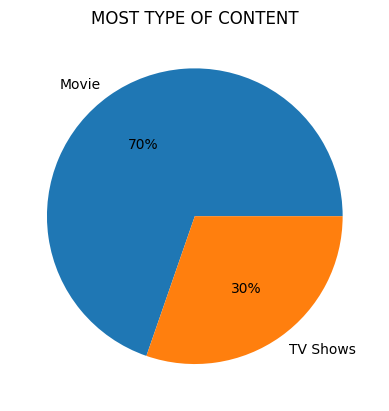

In [14]:
plt.pie(most_type, labels = ['Movie', 'TV Shows'], autopct='%.0f%%')
plt.title('MOST TYPE OF CONTENT')
plt.show()

In [15]:


rating_count = data['rating'].value_counts()
rating_count

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [16]:
rating_count = data['rating'].value_counts().reset_index().sort_values(by = 'count', ascending = False)

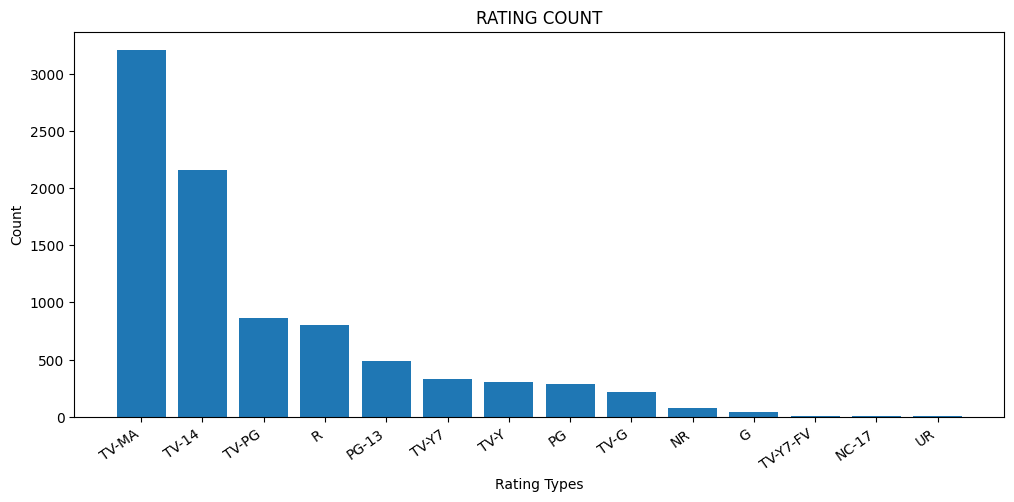

In [17]:
plt.figure(figsize = (12, 5))
plt.bar(rating_count['rating'], rating_count['count'])
plt.title('RATING COUNT')
plt.xticks(rotation=35, ha='right')
plt.xlabel('Rating Types')
plt.ylabel('Count')
plt.show()

In [18]:
country_count = data['country'].value_counts()
country_count

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
                  ... 
Iran                 1
West Germany         1
Greece               1
Zimbabwe             1
Soviet Union         1
Name: count, Length: 86, dtype: int64

In [19]:
country_count = data['country'].value_counts().head(10).reset_index().sort_values(by = 'count', ascending = False)

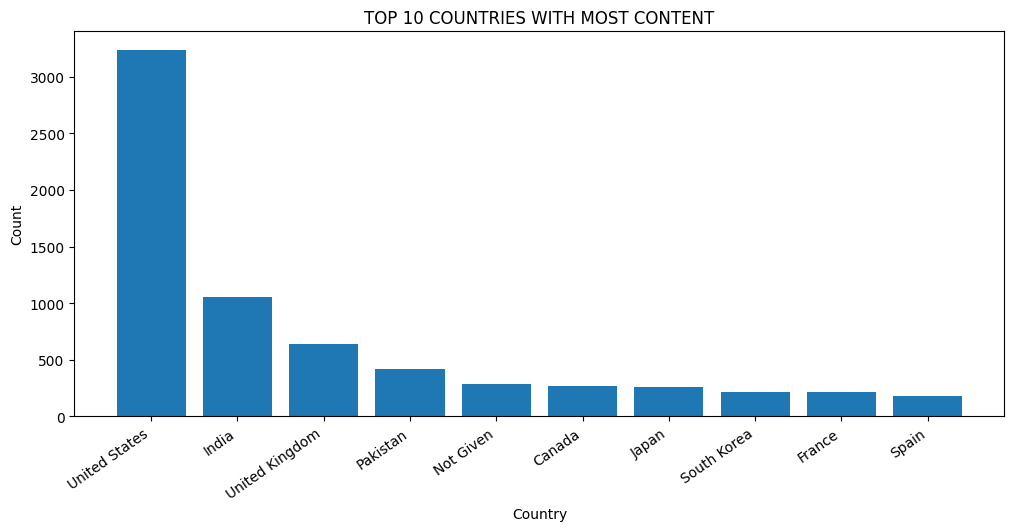

In [20]:
plt.figure(figsize = (12, 5))
plt.bar(country_count['country'], country_count['count'])
plt.title('TOP 10 COUNTRIES WITH MOST CONTENT')
plt.xticks(rotation=35, ha='right')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

In [21]:
movie_genre = data[data['type']== 'Movie'].groupby('listed_in').size().reset_index(name = 'count').sort_values(by = 'count', ascending = False)[:10]
tv_genre = data[data['type']== 'TV Show'].groupby('listed_in').size().reset_index(name = 'count').sort_values(by = 'count', ascending = False)[:10]


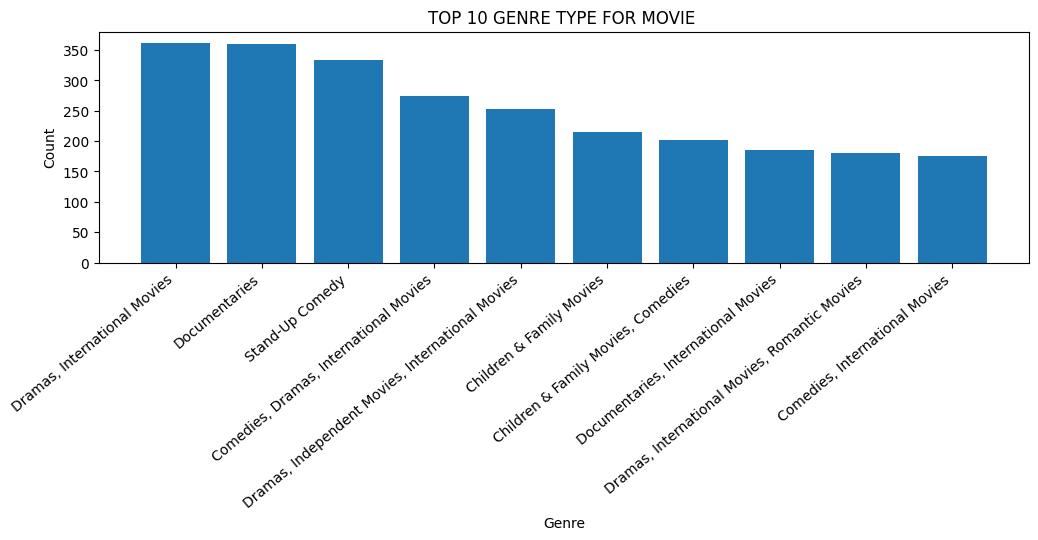

In [24]:
plt.figure(figsize = (12, 3))
plt.bar(movie_genre['listed_in'], movie_genre['count'])
plt.title('TOP 10 GENRE TYPE FOR MOVIE ')
plt.xticks(rotation=40, ha='right')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

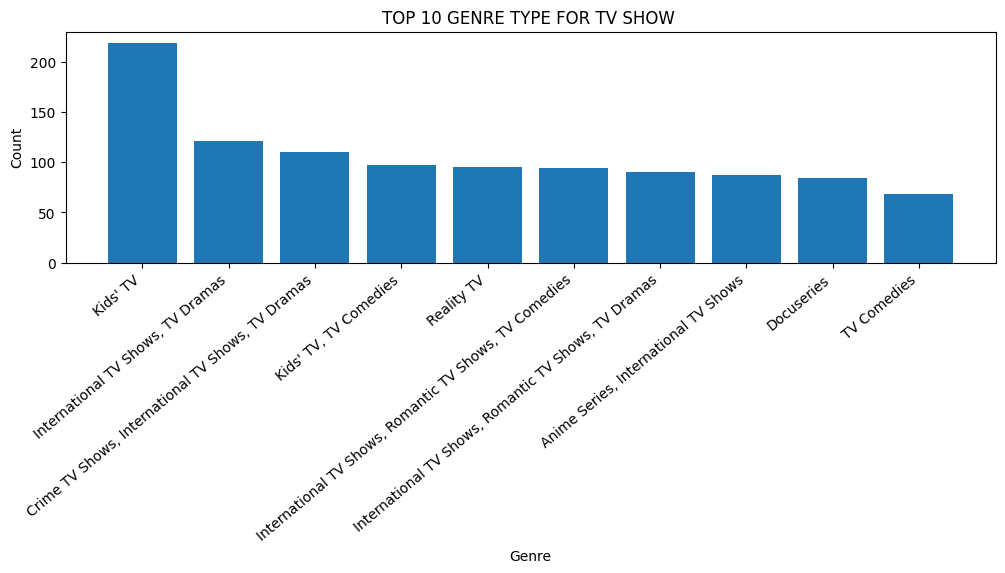

In [25]:
plt.figure(figsize = (12, 3))
plt.bar(tv_genre['listed_in'], tv_genre['count'])
plt.title('TOP 10 GENRE TYPE FOR TV SHOW ')
plt.xticks(rotation=40, ha='right')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

In [32]:
most_content_director = data['director'].value_counts()
most_content_director

director
Not Given                         2588
Rajiv Chilaka                       20
Alastair Fothergill                 18
Raúl Campos, Jan Suter              18
Suhas Kadav                         16
                                  ... 
Matt D'Avella                        1
Parthiban                            1
Scott McAboy                         1
Raymie Muzquiz, Stu Livingston       1
Mozez Singh                          1
Name: count, Length: 4528, dtype: int64

In [33]:
most_content_director = data['director'].value_counts().reset_index().sort_values(by = 'count', ascending = False)[:10]

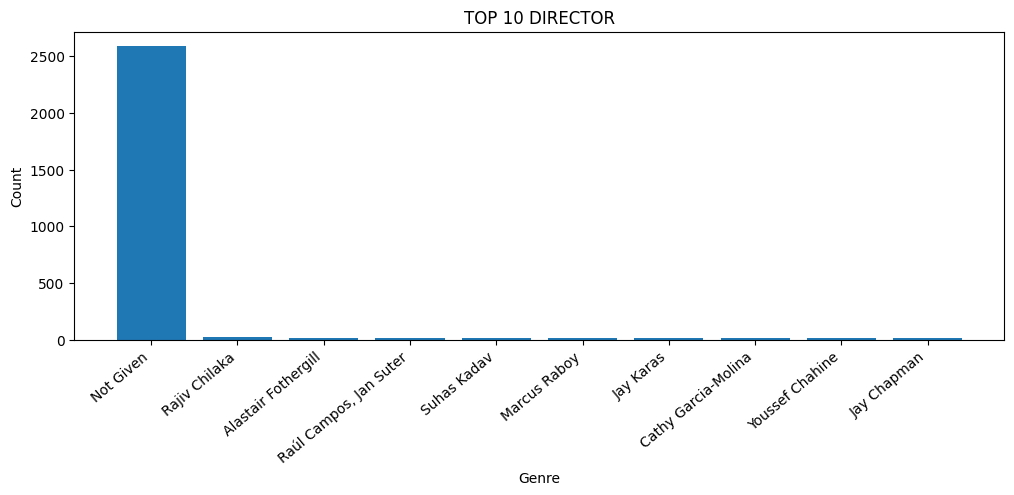

In [34]:
plt.figure(figsize = (12, 4))
plt.bar(most_content_director['director'], most_content_director['count'])
plt.title('TOP 10 DIRECTOR')
plt.xticks(rotation=40, ha='right')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()